In [3]:
# pip install tensor flow

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# generate synthetic datatsets
x,y = make_moons(n_samples=1000,noise=0.2,random_state=42)
print(x)
print("___________________________________")
print(y)

[[-0.11166654  0.52022374]
 [ 1.14264982 -0.34257734]
 [ 0.79555796 -0.01144231]
 ...
 [ 1.72760808 -0.42882943]
 [-1.01448644  0.13522904]
 [ 0.77438101  0.63428493]]
___________________________________
[1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1

In [4]:
x.shape,y.shape

((1000, 2), (1000,))

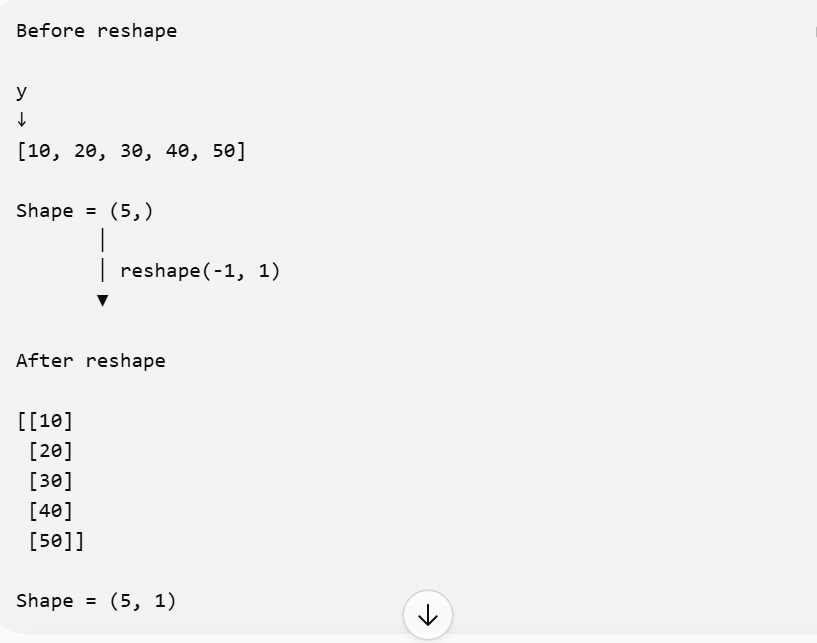

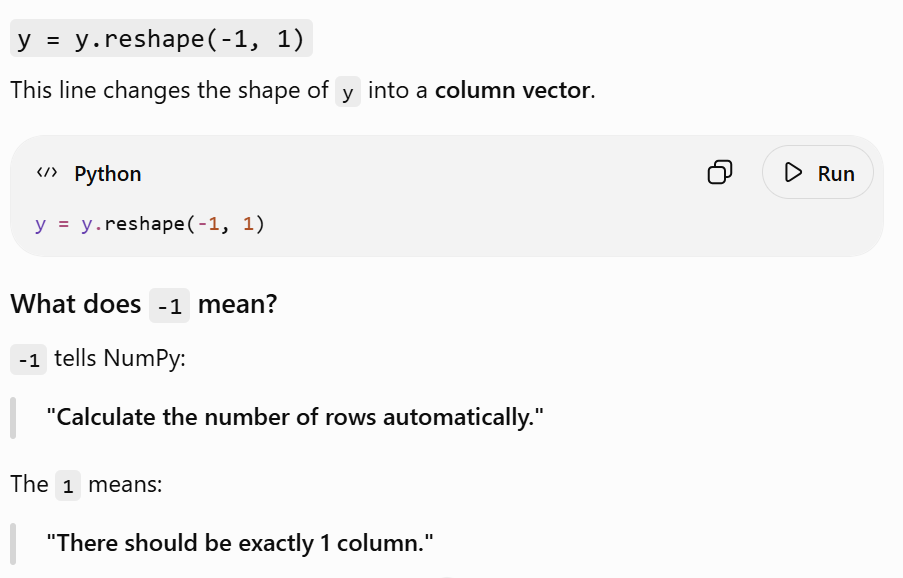

In [5]:
y=y.reshape(-1,1)#Reshape for consistency
y.shape

(1000, 1)

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [7]:
y_train

array([[1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
    

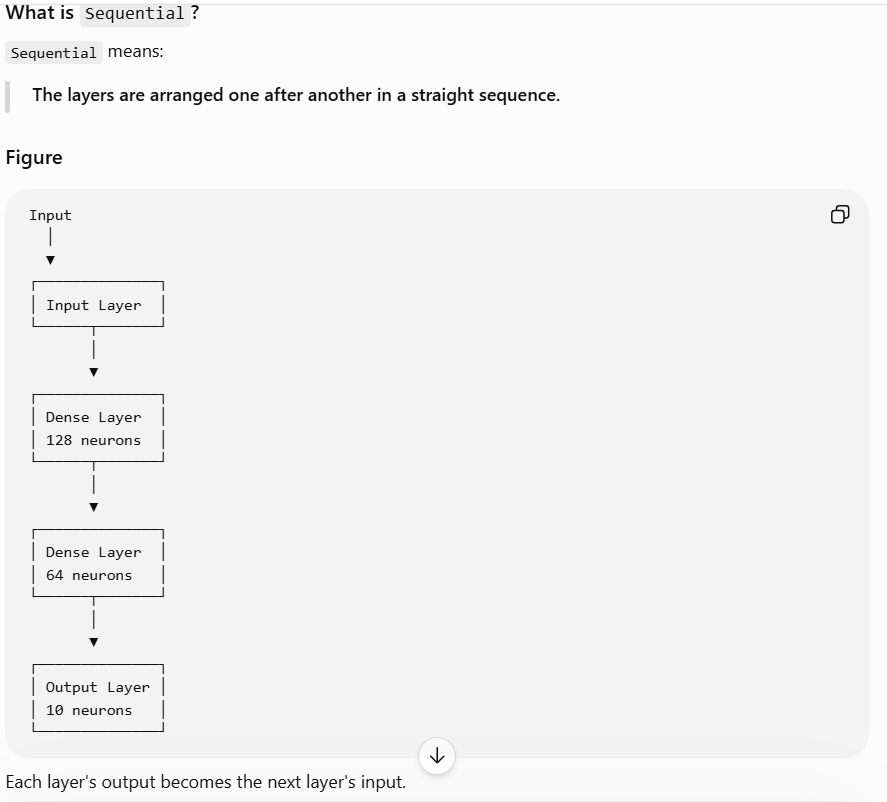

In [10]:
# build a sequential model
def build_linear_model():
  model=Sequential([
      Dense(4,activation='linear',input_dim=2),# First layer with linear activation
      Dense(1,activation='sigmoid')# Output layer for binary classification
      ])
  model.compile(optimizer=Adam(learning_rate=0.01),loss='binary_crossentropy',metrics=['accuracy'])
  return model

# Build a Sequential model with ReLU activation
def build_model_relu():
  model=Sequential([
      Dense(4,activation='relu',input_dim=2),
      Dense(1,activation='sigmoid')
  ])
  model.compile(optimizer=Adam(learning_rate=0.01),loss='binary_crossentropy',metrics=['accuracy'])
  return model

# Train and evaluate the models
def train_and_evaluate(model,x_train,y_train,x_test,y_test,epochs=50,batch_size=32):
  model.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,verbose=0)
  y_pred = (model.predict(x_test)>0.5).astype(int)
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy,y_pred

# intialize models
linear_model = build_linear_model()
relu_model = build_model_relu()

# train and evaluate linear model
print("Training linear model ......")
linear_accuracy,linear_preds = train_and_evaluate(linear_model,x_train,y_train,x_test,y_test)
print(f"Accuracy with linear actcivation: {linear_accuracy:.2f}")

# train evaluate RELU model
print("Training RELU model ......")
relu_accuracy,relu_preds = train_and_evaluate(relu_model,x_train,y_train,x_test,y_test)
print(f"Accuracy with linear actcivation: {relu_accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training linear model ......


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy with linear actcivation: 0.85
Training RELU model ......


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy with linear actcivation: 0.85



Visualizing decision boundaries...
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


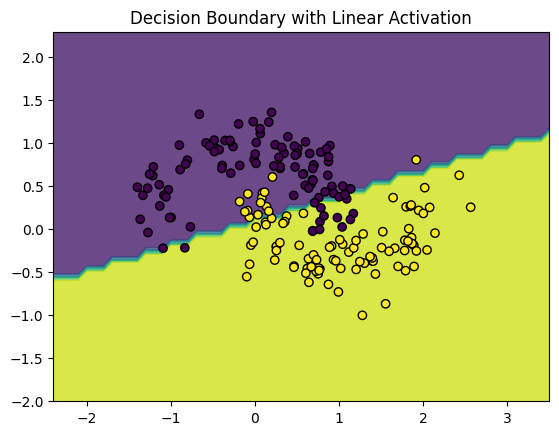

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


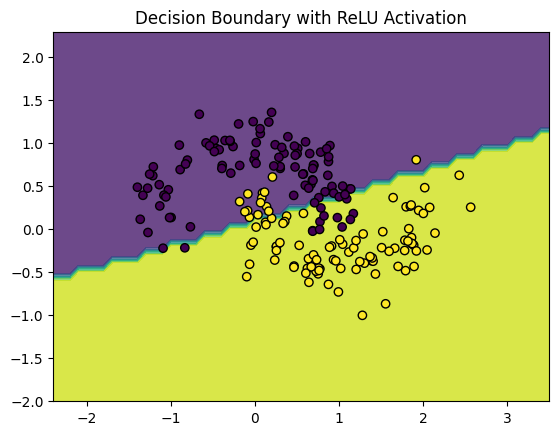

In [12]:
def plot_decision_boundary(model,x,y,title):
  x_min,x_max = x[:,0].min()-1,x[:,0].max() +1
  y_min,y_max = x[:,1].min()-1,x[:,1].max()+1
  xx,yy = np.meshgrid(np.arange(x_min,x_max,0.1),
                      np.arange(y_min,y_max,0.1))
  grid = np.c_[xx.ravel(),yy.ravel()]
  z = model.predict(grid)
  z = (z>0.5).astype(int).reshape(xx.shape)
  plt.contourf(xx,yy,z,alpha=0.8)
  plt.scatter(x[:,0],x[:,1],c=y.flatten(),edgecolors='k')
  plt.title(title)
  plt.show()

  # Plot decision boundaries
print("\nVisualizing decision boundaries...")
plot_decision_boundary(linear_model, x_test, y_test, "Decision Boundary with Linear Activation")
plot_decision_boundary(relu_model, x_test, y_test, "Decision Boundary with ReLU Activation")